# **1. Setup and Get Data**


**1.1 Install Dependencies and Setup**


In [ ]:
#!pip install labelme tensorflow opencv-python matplotlib albumentations

# if you have NVIDIA GPU
# pip install tensorflow-gpu

In [1]:
import albumentations as alb
import cv2
import numpy as np
import tensorflow as tf

print("OK")

OK


**1.2 Collect Images**


In [2]:
import os
import time
import uuid

In [3]:
IMAGES_PATH = os.path.join('data', 'images')
number_images = 30

In [52]:
cap = cv2.VideoCapture(0)
for imgnum in range(number_images):
    print('Collecting image {}'.format(imgnum))
    ret, frame = cap.read()
    imgname = os.path.join(IMAGES_PATH,f'{str(uuid.uuid1())}.jpg')
    cv2.imwrite(imgname, frame)
    cv2.imshow('frame', frame)
    time.sleep(0.5)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

OpenCV: camera access has been denied. Either run 'tccutil reset Camera' command in same terminal to reset application authorization status, either modify 'System Preferences -> Security & Privacy -> Camera' settings for your application.
OpenCV: camera failed to properly initialize!


error: OpenCV(4.8.1) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgcodecs/src/loadsave.cpp:787: error: (-215:Assertion failed) !_img.empty() in function 'imwrite'


**1.3 Annotate Images with LabelMe**


In [ ]:
!labelme # or use other annotation tools

# **2. Review Dataset and Build Image Loading Function**


**2.1 Import TF and Deps**


In [4]:
import json
from matplotlib import pyplot as plt

**2.2 Limit GPU Memory Growth**


In [5]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu, True)

In [6]:
tf.config.list_physical_devices('GPU')

[]

**2.3 Load Image into TF Data Pipeline**


In [7]:
# For macOS
images = tf.data.Dataset.list_files('data/images/*.jpg')

# For Windows
# images = tf.data.Dataset.list_files('data\\images\\*.jpg')

In [8]:
images.as_numpy_iterator().next()

b'data/images/e77a45b6-37b8-11f1-9016-0242ac1c000c.jpg'

In [9]:
def load_image(x):
  byte_img = tf.io.read_file(x)
  img = tf.io.decode_jpeg(byte_img)
  return img

In [10]:
images = images.map(load_image)

In [11]:
images.as_numpy_iterator().next()

array([[[114,  98,  85],
        [115,  99,  86],
        [116,  98,  86],
        ...,
        [217, 222, 225],
        [216, 221, 224],
        [215, 220, 223]],

       [[112,  96,  83],
        [113,  97,  84],
        [115,  97,  85],
        ...,
        [215, 220, 223],
        [214, 219, 222],
        [214, 219, 222]],

       [[113,  97,  84],
        [113,  97,  84],
        [115,  97,  85],
        ...,
        [215, 219, 220],
        [214, 218, 221],
        [213, 217, 220]],

       ...,

       [[ 69,  22,  16],
        [ 73,  26,  20],
        [ 74,  27,  21],
        ...,
        [ 88,  96,  75],
        [ 88,  97,  78],
        [ 91, 100,  81]],

       [[ 74,  25,  21],
        [ 79,  32,  26],
        [ 82,  35,  29],
        ...,
        [ 88,  95,  77],
        [ 87,  96,  77],
        [ 90,  99,  80]],

       [[ 94,  45,  41],
        [101,  52,  48],
        [101,  54,  48],
        ...,
        [ 88,  95,  77],
        [ 87,  96,  77],
        [ 90,  99,  80]]

In [12]:
type(images)

tensorflow.python.data.ops.map_op._MapDataset

**2.4 View Raw Images with Mathplotlib**


In [13]:
image_generator = images.batch(4).as_numpy_iterator()

In [14]:
plot_images = image_generator.next()

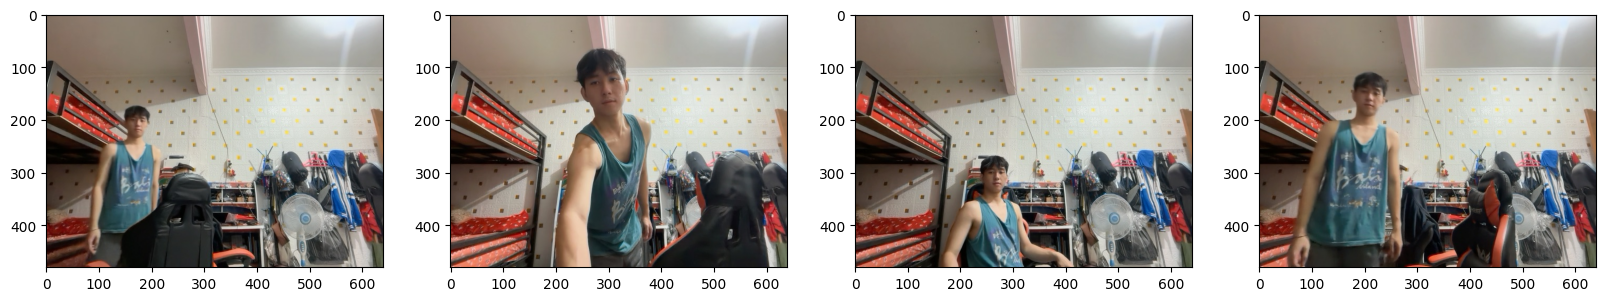

In [15]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
  ax[idx].imshow(image)
plt.show()

# **3. Partition Unaugmented Data**


**3.1 MANUALLY SPLIT DATA INTO TRAIN TEST AND VAL**


In [66]:
90*.7 # 63 to train

62.99999999999999

In [67]:
90*.15 # 14 and 13 to test and val

13.5

**3.2 Move the Matching Labels**


In [68]:
for folder in ['train', 'test', 'val']:
    for file in os.listdir(os.path.join('data', folder, 'images')):

        filename = file.split('.')[0]+'.json'
        existing_filepath = os.path.join('data', 'labels', filename)
        if os.path.exists(existing_filepath):
            new_filepath = os.path.join('data', folder, 'labels', filename)
            os.replace(existing_filepath, new_filepath)

# **4. Apply Image Augmentation on Images and Labels using Albumentation**


**4.1 Setup Albumentations Transform Pipeline**


In [18]:
augmentor = alb.Compose(
    [
        alb.RandomCrop(width=450, height=450),
        alb.HorizontalFlip(p=0.5),
        alb.RandomBrightnessContrast(p=0.2),
        alb.RandomGamma(p=0.2),
        alb.RGBShift(p=0.2),
        alb.VerticalFlip(p=0.5),
    ], bbox_params=alb.BboxParams(format='albumentations', label_fields=['class_labels'])
)

**4.2 Load a Test Image and Annotation with OpenCV and JSON**


In [19]:
sample_image_filepath = tf.data.Dataset.list_files('data/train/images/*.jpg').as_numpy_iterator().next().decode('utf-8')
img = cv2.imread(sample_image_filepath)


In [20]:
sample_label_filepath = os.path.join(
    'data',
    'labels',
    f"{os.path.splitext(os.path.basename(sample_image_filepath))[0]}.json"
)

with open(sample_label_filepath, 'r') as f:
    label_data = json.load(f)

In [21]:
label_data['shapes'][0]['points']

[[223.15789473684208, 182.63157894736844],
 [345.7894736842105, 308.42105263157896]]

**4.3 Extract Coordinates and Rescale to Match Image Resolution**


In [22]:
coords = [0,0,0,0]
coords[0] = label_data['shapes'][0]['points'][0][0]
coords[1] = label_data['shapes'][0]['points'][0][1]
coords[2] = label_data['shapes'][0]['points'][1][0]
coords[3] = label_data['shapes'][0]['points'][1][1]

In [23]:
coords

[223.15789473684208, 182.63157894736844, 345.7894736842105, 308.42105263157896]

In [24]:
coords = list(np.divide(coords, [640, 480, 640, 480]))

In [25]:
coords

[0.34868421052631576,
 0.3804824561403509,
 0.540296052631579,
 0.6425438596491229]

**4.4 Apply Augmentation and View Results**


In [26]:
augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])

In [27]:
augmented['bboxes'][0][2:]

(0.5085380116959065, 0.6408187134502923)

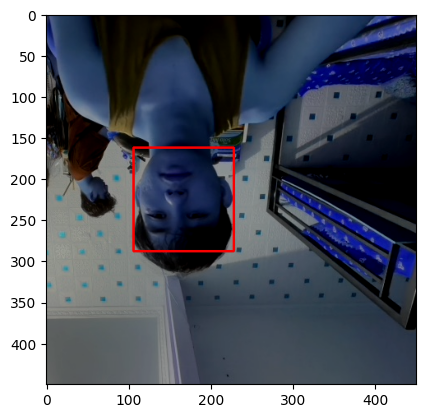

In [28]:
cv2.rectangle(augmented['image'],
              tuple(np.multiply(augmented['bboxes'][0][:2], [450,450]).astype(int)),
              tuple(np.multiply(augmented['bboxes'][0][2:], [450,450]).astype(int)),
              (250,0,0),
              2
              )
plt.imshow(augmented['image'])

# **5. Build and Run Augmentation Pipeline**


**5.1 Run Augmentation Pipeline**


In [99]:
for partition in ['train', 'test', 'val']:
    for image in os.listdir(os.path.join('data', partition, 'images')):
        img = cv2.imread(os.path.join('data', partition, 'images', image))

        cords = [0,0,0.00001,0.00001]
        label_path = os.path.join('data', partition, 'labels', f'{image.split(".")[0]}.json')
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                label = json.load(f)

            coords[0] = label['shapes'][0]['points'][0][0]
            coords[1] = label['shapes'][0]['points'][0][1]
            coords[2] = label['shapes'][0]['points'][1][0]
            coords[3] = label['shapes'][0]['points'][1][1]
            coords = list(np.divide(coords, [640,480,640,480]))
        
        try:
            for x in range(60):
                augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])
                cv2.imwrite(os.path.join('aug_data', partition, 'images', f'{image.split(".")[0]}.{x}.jpg'), augmented['image'])

                annotation = {}
                annotation['image'] = image

                if os.path.exists(label_path):
                    if len(augmented['bboxes']) == 0:
                        annotation['bbox'] = [0,0,0,0]
                        annotation['class'] = 0
                    else:
                        annotation['bbox'] = augmented['bboxes'][0]
                        annotation['class'] = 1
                else:
                    annotation['bbox'] = [0,0,0,0]
                    annotation['class'] = 0

                with open(os.path.join('aug_data', partition, 'labels', f'{image.split(".")[0]}.{x}.json'), 'w') as f:
                    json.dump(annotation, f)
        except Exception as e:
            print(e)

x_max is less than or equal to x_min for bbox [0.59375, 0.6567982456140352, 0.43832236842105265, 0.41666666666666674, 'face'].
x_max is less than or equal to x_min for bbox [0.5353618421052632, 0.4046052631578948, 0.37417763157894735, 0.18311403508771934, 'face'].
x_max is less than or equal to x_min for bbox [0.3453947368421052, 0.6896929824561404, 0.25082236842105265, 0.5241228070175439, 'face'].


**5.2 Load Augmented Images to Tensorflow Dataset**


In [16]:
train_images = tf.data.Dataset.list_files('aug_data/train/images/*.jpg', shuffle=False)
# For Windows: train_images = tf.data.Dataset.list_files('aug_data\\train\\images\\*.jpg', shuffle=False)

train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (120,120)))
train_images = train_images.map(lambda x: x/255)

In [17]:
test_images = tf.data.Dataset.list_files('aug_data/test/images/*.jpg', shuffle=False)
# For Windows: test_images = tf.data.Dataset.list_files('aug_data\\test\\images\\*.jpg', shuffle=False)

test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (120,120)))
test_images = test_images.map(lambda x: x/255)

In [18]:
val_images = tf.data.Dataset.list_files('aug_data/val/images/*.jpg', shuffle=False)
# For Windows: val_images = tf.data.Dataset.list_files('aug_data\\val\\images\\*.jpg', shuffle=False)

val_images = val_images.map(load_image)
val_images = val_images.map(lambda x: tf.image.resize(x, (120,120)))
val_images = val_images.map(lambda x: x/255)

In [19]:
train_images.as_numpy_iterator().next()

array([[[0.59460783, 0.5269608 , 0.3372549 ],
        [0.53302693, 0.47126225, 0.28008577],
        [0.48321077, 0.43204656, 0.25557598],
        ...,
        [0.5418505 , 0.28958333, 0.1189951 ],
        [0.484375  , 0.22181372, 0.09479167],
        [0.39908087, 0.23431373, 0.11360294]],

       [[0.6460784 , 0.5808824 , 0.40061274],
        [0.5824142 , 0.5172181 , 0.33633578],
        [0.5323529 , 0.47745097, 0.3009804 ],
        ...,
        [0.35759804, 0.22708334, 0.1257353 ],
        [0.34479168, 0.265625  , 0.18419118],
        [0.33069852, 0.30189952, 0.21905637]],

       [[0.68333334, 0.6284314 , 0.45196077],
        [0.61960787, 0.5647059 , 0.3882353 ],
        [0.5686275 , 0.5137255 , 0.32941177],
        ...,
        [0.47346812, 0.43235293, 0.34607843],
        [0.5203431 , 0.4452206 , 0.36243874],
        [0.7334559 , 0.6113971 , 0.5251225 ]],

       ...,

       [[0.84724265, 0.9648897 , 0.925674  ],
        [0.84270835, 0.9603554 , 0.92015934],
        [0.8392157 , 0

# **6. Prepare Labels**


**6.1 Build Label Loading Function**


In [20]:
def load_labels(label_path):
    with open(label_path.numpy(), 'r', encoding= "utf-8") as f:
        label = json.load(f)

    return [label['class']], label['bbox']

In [21]:
def process_labels(x):
    classes, bbox = tf.py_function(load_labels, [x], [tf.uint8, tf.float16])

    classes.set_shape([1])
    bbox.set_shape([4])

    return classes, bbox

**6.2 Load Labels to Tensorflow Dataset**


In [22]:
train_labels = tf.data.Dataset.list_files('aug_data/train/labels/*.json', shuffle=False)
train_labels = train_labels.map(process_labels)

In [23]:
test_labels = tf.data.Dataset.list_files('aug_data/test/labels/*.json', shuffle=False)
test_labels = test_labels.map(process_labels)

In [24]:
val_labels = tf.data.Dataset.list_files('aug_data/val/labels/*.json', shuffle=False)
val_labels = val_labels.map(process_labels)

In [25]:
train_labels.as_numpy_iterator().next()

(array([1], dtype=uint8),
 array([0.2512, 0.3389, 0.4932, 0.638 ], dtype=float16))

# **7. Combine Label and Image Samples**


**7.1 Check Partition Lengths**


In [26]:
len(train_images), len(train_labels), len(test_images), len(test_labels), len(val_images), len(val_labels)

(3600, 3600, 840, 840, 780, 780)

**7.2 Create Final Datasets (Images/Labels)**


In [27]:
train = tf.data.Dataset.zip((train_images, train_labels))
train = train.shuffle(5000)
train = train.batch(8)
train = train.prefetch(4)

In [28]:
test = tf.data.Dataset.zip((test_images, test_labels))
test = test.shuffle(1300)
test = test.batch(8)
test = test.prefetch(4)

In [29]:
val = tf.data.Dataset.zip((val_images, val_labels))
val = val.shuffle(1000)
val = val.batch(8)
val = val.prefetch(4)

In [30]:
train.as_numpy_iterator().next()[0].shape

(8, 120, 120, 3)

**7.3 View Images and Annotations**


In [31]:
data_samples = train.as_numpy_iterator()

In [32]:
res = data_samples.next()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


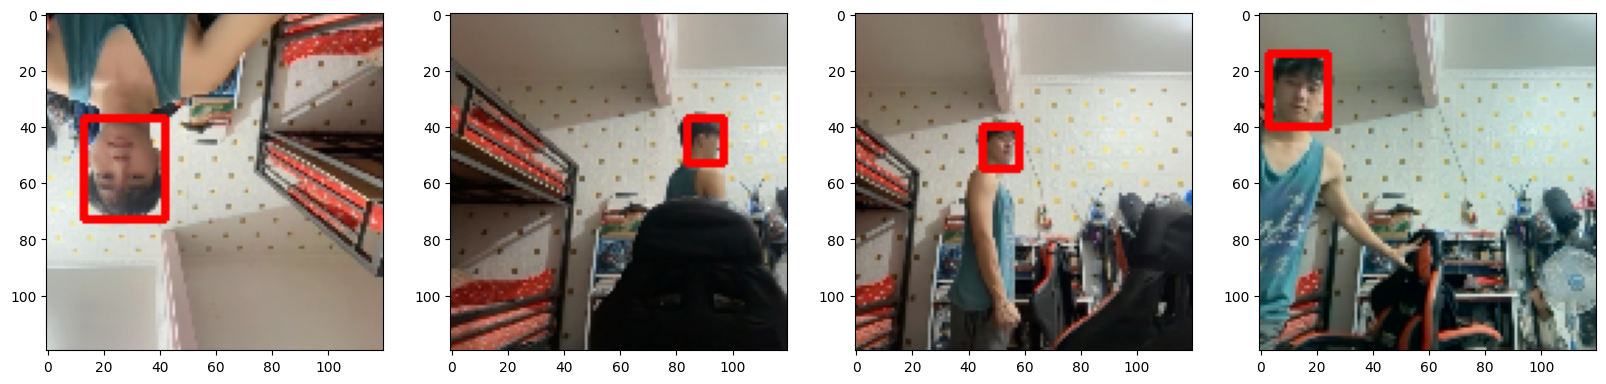

In [33]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4):
    sample_image = res[0][idx]
    sample_coords = res[1][1][idx]

    cv2.rectangle(sample_image,
                  tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                  tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)),
                  (255,0,0), 2)
    
    ax[idx].imshow(sample_image)

# **8. Build Deep Learning using the Functional API**


**8.1 Import Layers and Base Network**


In [34]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, GlobalMaxPooling2D
from tensorflow.keras.applications import VGG16

**8.2 Download VGG16**


In [35]:
vgg = VGG16(include_top=False)

In [36]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

**8.3 Build instance of Network**


In [37]:
def build_model():
    input_layer = Input(shape=(120,120,3))

    vgg = VGG16(include_top=False)(input_layer)

    # Classification Model
    f1 = GlobalMaxPooling2D()(vgg)
    class1 = Dense(2048, activation='relu')(f1)
    class2 = Dense(1, activation='sigmoid')(class1)

    # Bounding Box Model
    f2 = GlobalMaxPooling2D()(vgg)
    regress1 = Dense(2048, activation='relu')(f2)
    regress2 = Dense(4, activation='sigmoid')(regress1)

    facetracker = Model(inputs=input_layer, outputs=[class2, regress2])
    return facetracker

**8.4 Test out Neural Network**


In [38]:
facetracker = build_model()

In [39]:
facetracker.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 120, 120,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 3, 3, 512) │ 14,714,688 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2048)      │  1,050,624 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2048)      │  1,050,624 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      2,049 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │      8,196 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,826,181 (64.19 MB)

 Trainable params: 16,826,181 (64.19 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
X, y = train.as_numpy_iterator().next()

In [41]:
X.shape

(8, 120, 120, 3)

In [42]:
classes, coords = facetracker.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


In [43]:
classes, coords

(array([[0.45579442],
        [0.44129586],
        [0.4959836 ],
        [0.42886722],
        [0.39329636],
        [0.5114549 ],
        [0.477805  ],
        [0.4083004 ]], dtype=float32),
 array([[0.5001991 , 0.33789518, 0.639584  , 0.4580743 ],
        [0.42531094, 0.34845808, 0.6602542 , 0.4393582 ],
        [0.6073926 , 0.36000815, 0.62801623, 0.4294105 ],
        [0.47850809, 0.3435855 , 0.6624519 , 0.4885886 ],
        [0.41617975, 0.39897618, 0.6052695 , 0.45097497],
        [0.555241  , 0.3257024 , 0.60235894, 0.5090683 ],
        [0.4458501 , 0.33361763, 0.6830293 , 0.47920614],
        [0.5023804 , 0.38478532, 0.57737875, 0.48045418]], dtype=float32))

# **9. Define Losses and Optimizers**


**9.1 Define Optimizer and LR**


In [44]:
batches_per_epoch = len(train)
lr_decay = (1./0.75 - 1)/batches_per_epoch

In [45]:
opt = tf.keras.optimizers.Adam(learning_rate=0.0001, decay=lr_decay)

/Users/stephan/miniconda3/envs/keras-dl/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


**9.2 Create Localization Loss and Classification Loss**


In [46]:
def localization_loss(y_true, yhat):
    delta_coord = tf.reduce_sum(tf.square(y_true[:,:2] - yhat[:,:2]))

    h_true = y_true[:,3] - y_true[:,1]
    w_true = y_true[:,2] - y_true[:,0]

    h_pred = yhat[:,3] - yhat[:,1]
    w_pred = yhat[:,2] - yhat[:,0]

    delta_size = tf.reduce_sum(tf.square(w_true-w_pred) + tf.square(h_true-h_pred))

    return delta_coord + delta_size

In [47]:
classloss = tf.keras.losses.BinaryCrossentropy()
regressloss = localization_loss

**9.3 Test out Loss Metrics**


In [48]:
localization_loss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=0.5048872828483582>

In [49]:
classloss(y[0], classes)

<tf.Tensor: shape=(), dtype=float32, numpy=0.7986957430839539>

In [50]:
regressloss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=0.5048872828483582>

# **10. Train Neural Network**


**10.1 Create Custom Model Class**


In [51]:
class FaceTracker(Model): 
    def __init__(self, eyetracker,  **kwargs): 
        super().__init__(**kwargs)
        self.model = eyetracker

    def compile(self, opt, classloss, localizationloss, **kwargs):
        super().compile(**kwargs)
        self.closs = classloss
        self.lloss = localizationloss
        self.opt = opt
    
    def train_step(self, batch, **kwargs): 
        
        X, y = batch
        
        with tf.GradientTape() as tape: 
            classes, coords = self.model(X, training=True)
            
            batch_classloss = self.closs(y[0], classes)
            batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
            
            total_loss = batch_localizationloss+0.5*batch_classloss
            
            grad = tape.gradient(total_loss, self.model.trainable_variables)
        
        opt.apply_gradients(zip(grad, self.model.trainable_variables))
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
    
    def test_step(self, batch, **kwargs): 
        X, y = batch
        
        classes, coords = self.model(X, training=False)
        
        batch_classloss = self.closs(y[0], classes)
        batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
        total_loss = batch_localizationloss+0.5*batch_classloss
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
        
    def call(self, X, **kwargs): 
        return self.model(X, **kwargs)

In [52]:
model = FaceTracker(facetracker)

In [53]:
model.compile(opt, classloss, regressloss)

**10.2 Train**


In [54]:
logdir='logs'

In [55]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [56]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20


I0000 00:00:1776266296.022505 19079721 service.cc:153] XLA service 0x36f9fe360 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776266296.022517 19079721 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1776266296.026949 19079721 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


450/450 ━━━━━━━━━━━━━━━━━━━━ 156s 341ms/step - class_loss: 0.0291 - regress_loss: 0.0625 - total_loss: 0.0771 - val_class_loss: 1.3716 - val_regress_loss: 0.4307 - val_total_loss: 1.1165
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 161s 358ms/step - class_loss: 6.7813e-04 - regress_loss: 0.0055 - total_loss: 0.0058 - val_class_loss: 1.2431e-04 - val_regress_loss: 0.0083 - val_total_loss: 0.0084
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 162s 359ms/step - class_loss: 1.5137e-04 - regress_loss: 0.0089 - total_loss: 0.0090 - val_class_loss: 2.4226 - val_regress_loss: 0.6835 - val_total_loss: 1.8948
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 164s 363ms/step - class_loss: 2.6299e-05 - regress_loss: 0.0136 - total_loss: 0.0137 - val_class_loss: 2.4840 - val_regress_loss: 0.9229 - val_total_loss: 2.1649
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 159s 353ms/step - class_loss: 1.6491e-05 - regress_loss: 0.0180 - total_loss: 0.0180 - val_class_loss: 1.8469e-04 - val_regress_loss: 0.0126 - val_total_loss: 0.01

**10.3 Plot Performance**


In [57]:
hist.history

{'class_loss': [0.02906365878880024,
  0.0006781329866498709,
  0.00015136868751142174,
  2.6298856028006412e-05,
  1.649110345169902e-05,
  0.011061107739806175,
  9.180709457723424e-05,
  0.0020358171314001083,
  0.00025355012621730566,
  2.9030150471953675e-05,
  4.6728695451747626e-05,
  2.5576209736755118e-05,
  0.00013624013809021562,
  2.558709638833534e-06,
  0.00020520336693152785,
  0.0001374171260977164,
  0.04988298565149307,
  2.512396895326674e-05,
  8.686488581588492e-05,
  6.825348009442678e-06],
 'regress_loss': [0.06252624094486237,
  0.0054847258143126965,
  0.008944793604314327,
  0.013637524098157883,
  0.017998106777668,
  0.03520238399505615,
  0.013649229891598225,
  0.013195252045989037,
  0.01269316766411066,
  0.003347724908962846,
  0.004893781617283821,
  0.0029219030402600765,
  0.0058648791164159775,
  0.005687942262738943,
  0.010739471763372421,
  0.0037231063470244408,
  0.005702332593500614,
  0.0018677421612665057,
  0.0016045373631641269,
  0.004085

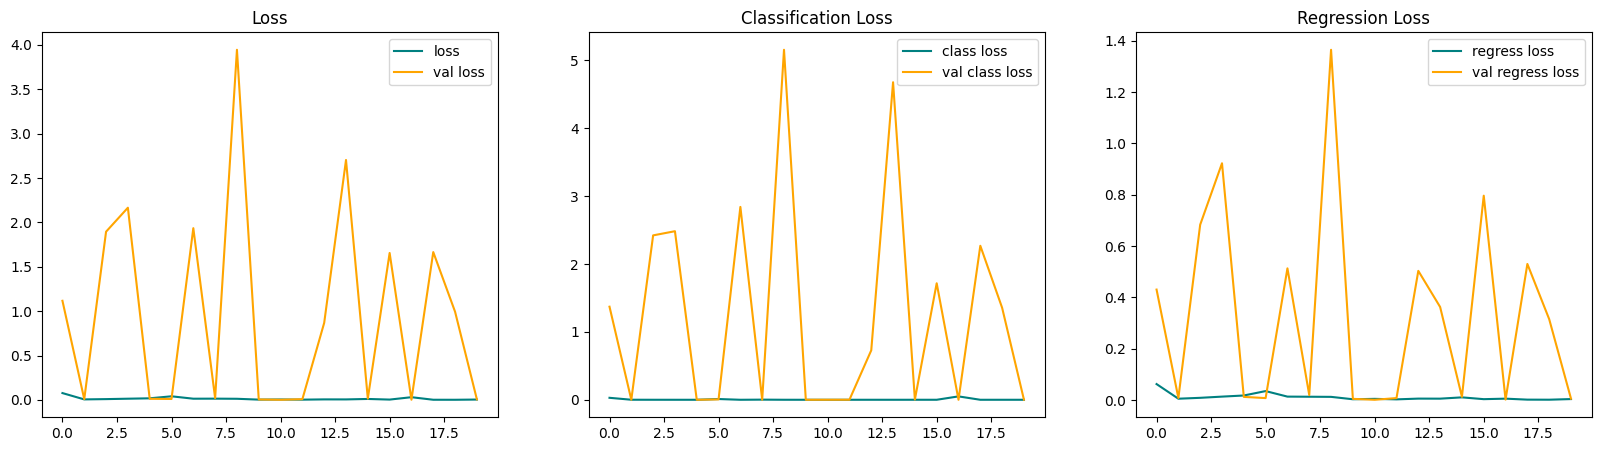

In [58]:
fig, ax = plt.subplots(ncols=3, figsize=(20,5))

ax[0].plot(hist.history['total_loss'], color='teal', label='loss')
ax[0].plot(hist.history['val_total_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss')
ax[0].legend()

ax[1].plot(hist.history['class_loss'], color='teal', label='class loss')
ax[1].plot(hist.history['val_class_loss'], color='orange', label='val class loss')
ax[1].title.set_text('Classification Loss')
ax[1].legend()

ax[2].plot(hist.history['regress_loss'], color='teal', label='regress loss')
ax[2].plot(hist.history['val_regress_loss'], color='orange', label='val regress loss')
ax[2].title.set_text('Regression Loss')
ax[2].legend()

plt.show()

# **11. Make Predictions**


**11.1 Make Predictions on Test Set**


In [59]:
test_data = test.as_numpy_iterator()

In [60]:
test_sample = test_data.next()

In [61]:
yhat = facetracker.predict(test_sample[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


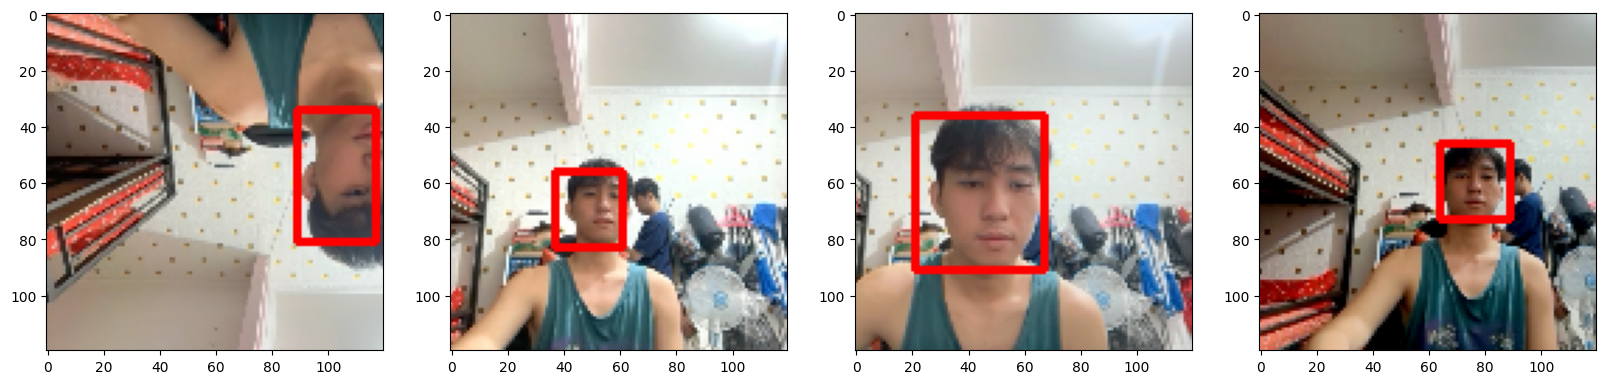

In [62]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4):
    sample_image = test_sample[0][idx]
    sample_coords = yhat[1][idx]

    if yhat[0][idx] > 0.5:
        cv2.rectangle(sample_image,
                      tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)),
                      (255,0,0),2)
    ax[idx].imshow(sample_image)

**11.2 Save the Model**


In [66]:
from tensorflow.keras.models import load_model

In [67]:
facetracker.save('facetracker.h5')

In [68]:
facetracker = load_model('facetracker.h5')

**11.3 Real Time Detection**


In [78]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    _ , frame = cap.read()
    h, w, _ = frame.shape
    
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized = tf.image.resize(rgb, (120,120))
    
    yhat = facetracker.predict(np.expand_dims(resized/255,0))
    sample_coords = yhat[1][0]
    
    if yhat[0] > 0.5: 
        # Controls the main rectangle
        cv2.rectangle(frame, 
                      tuple(np.multiply(sample_coords[:2], [w,h]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [w,h]).astype(int)), 
                            (255,0,0), 2)
        # Controls the label rectangle
        cv2.rectangle(frame, 
                      tuple(np.add(np.multiply(sample_coords[:2], [w,h]).astype(int), 
                                    [0,-30])),
                      tuple(np.add(np.multiply(sample_coords[:2], [w,h]).astype(int),
                                    [80,0])), 
                            (255,0,0), -1)
        
        # Controls the text rendered
        cv2.putText(frame, 'face', tuple(np.add(np.multiply(sample_coords[:2], [w,h]).astype(int),
                                               [0,-5])),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
    
    cv2.imshow('EyeTrack', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

KeyboardInterrupt: 